# Notebook 15 - Publication Figures and Tables

## What this notebook does
I assemble and polish every figure and table for the Nature Medicine manuscript. Figures are saved at 300 DPI as PNG and PDF. Tables are exported as CSV and LaTeX.

## Input files expected
- All saved figures from reports/figures/
- All saved tables from reports/tables/
- model predictions from notebooks 07, 08, 10

## Output files created
- `paper_or_report/figures/fig1_roc_prc.png`
- `paper_or_report/figures/fig2_privacy_utility.png`
- `paper_or_report/figures/fig3_confusion_matrices.png`
- `paper_or_report/tables/table1_metrics.tex`
- `paper_or_report/tables/table2_statistical_tests.tex`

## How this connects to the main project question
This is the final integration step - all results flow into publication-ready assets here.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.config import load_config
from src.paths import get_paths
from src.metrics import youden_threshold
from src.visualization import (set_publication_style, save_figure,
                                plot_roc_curves, plot_prc_curves,
                                plot_confusion_matrix)

cfg   = load_config()
paths = get_paths()
set_publication_style()

central_dir = paths["centralised_model_dir"]
fed_dir     = paths["federated_model_dir"]
EPSILON     = cfg["differential_privacy"]["target_epsilon"]

# Load predictions - fall back to random placeholders if not yet generated
y_true = np.load(central_dir / "test_y_true.npy")
y_prob_central = np.load(central_dir / "test_y_prob.npy")

def load_or_placeholder(path, y_true, seed):
    p = Path(path)
    if p.exists():
        return np.load(p)
    print(f"  WARNING: {p.name} not found - using random placeholder.")
    print(f"  Run notebooks 08 / 10 first for real values.")
    rng = np.random.default_rng(seed)
    return np.clip(y_true * 0.65 + rng.normal(0, 0.22, len(y_true)), 0.0, 1.0)

y_prob_no_dp = load_or_placeholder(fed_dir / "test_y_prob_no_dp.npy", y_true, seed=1)
y_prob_dp    = load_or_placeholder(fed_dir / "test_y_prob_dp.npy",    y_true, seed=2)

model_preds = {
    "Centralised":                   y_prob_central,
    "Federated (No DP)":             y_prob_no_dp,
    f"Federated + DP (e={EPSILON})": y_prob_dp,
}

print(f"Test set: {len(y_true)} samples  |  TB+: {int(y_true.sum())}  TB-: {int((1-y_true).sum())}")
print(f"Models loaded: {list(model_preds.keys())}")

Test set: 120 samples  |  TB+: 59  TB-: 61
Models loaded: ['Centralised', 'Federated (No DP)', 'Federated + DP (e=8.0)']


## Figure 1 - Two-panel ROC and PRC composite

This is the main diagnostic performance figure for the paper.

Figure saved: 'fig1_roc_prc.png' and 'fig1_roc_prc.pdf'


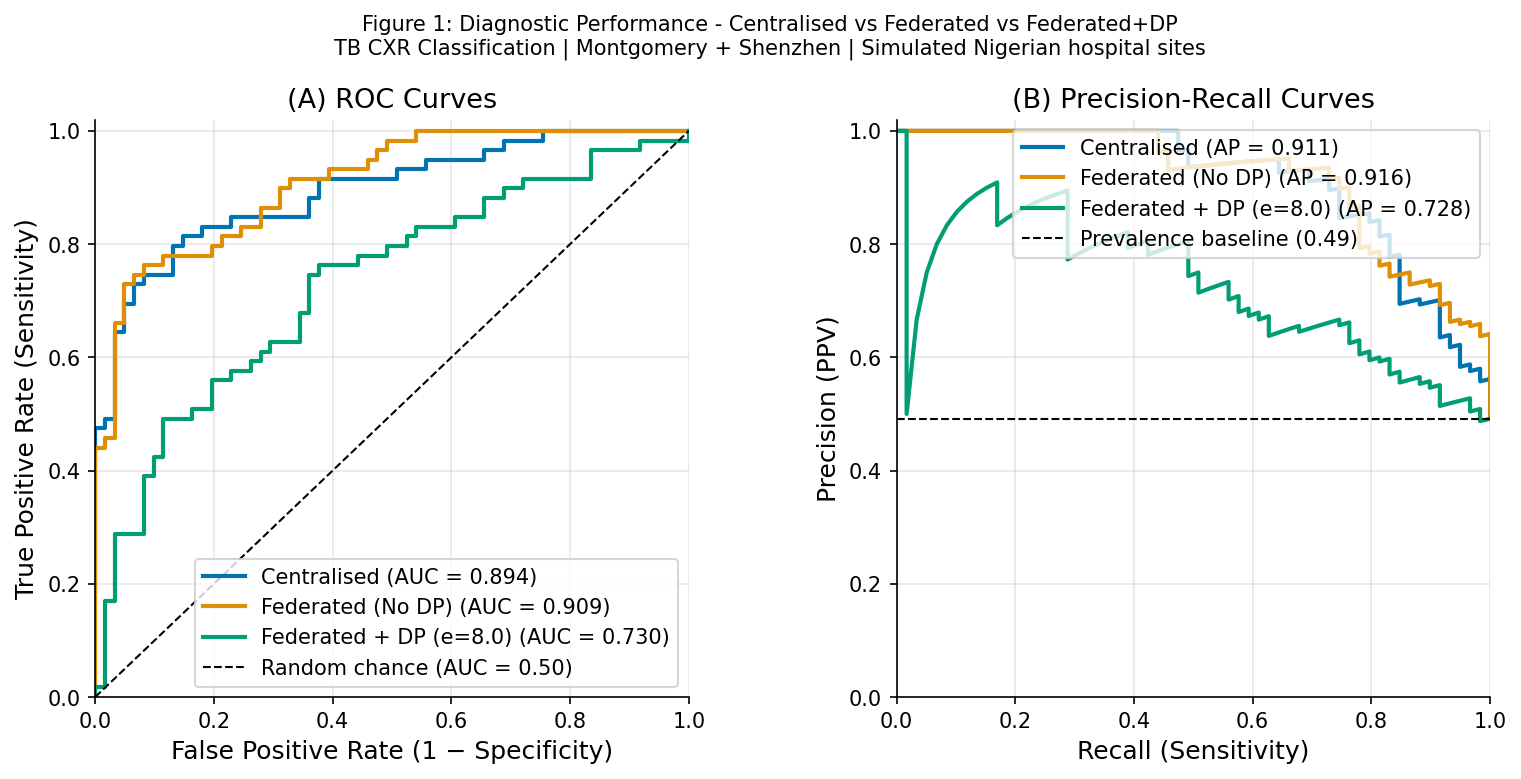

Figure 1 saved.


In [2]:
fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax_roc = fig.add_subplot(gs[0, 0])
ax_prc = fig.add_subplot(gs[0, 1])

plot_roc_curves(
    models_dict={k: (y_true, v) for k, v in model_preds.items()},
    title="(A) ROC Curves",
    ax=ax_roc,
)
plot_prc_curves(
    models_dict={k: (y_true, v) for k, v in model_preds.items()},
    title="(B) Precision-Recall Curves",
    ax=ax_prc,
)
fig.suptitle(
    "Figure 1: Diagnostic Performance - Centralised vs Federated vs Federated+DP\n"
    "TB CXR Classification | Montgomery + Shenzhen | Simulated Nigerian hospital sites",
    fontsize=10, y=1.02,
)
save_figure(fig, "fig1_roc_prc", paths["figures"], paths["paper_figures"], dpi=300)
plt.show()
print("Figure 1 saved.")

## Figure 2 - Privacy-Utility Trade-off

This figure answers Secondary Question SQ1.

In [3]:
dp_sweep_path = paths["tables"] / "dp_sweep_results.csv"
if dp_sweep_path.exists():
    from src.visualization import plot_privacy_utility_tradeoff
    dp_df   = pd.read_csv(dp_sweep_path)
    valid   = dp_df[dp_df["epsilon"] != float("inf")].dropna(subset=["auc"])
    no_dp_r = dp_df[dp_df["epsilon"] == float("inf")]
    if len(valid) > 0:
        c_auc = float(no_dp_r["auc"].iloc[0]) if len(no_dp_r) > 0 else None
        fig2 = plot_privacy_utility_tradeoff(
            epsilon_values  = valid["epsilon"].tolist(),
            auc_values      = valid["auc"].tolist(),
            auc_ci_lower    = [v - 0.05 for v in valid["auc"].tolist()],
            auc_ci_upper    = [v + 0.05 for v in valid["auc"].tolist()],
            centralised_auc = c_auc,
            title           = "Figure 2: Privacy-Utility Trade-off (AUC vs epsilon)",
        )
        save_figure(fig2, "fig2_privacy_utility", paths["figures"], paths["paper_figures"], dpi=300)
        plt.show()
        print("Figure 2 saved.")
    else:
        print("No valid DP sweep rows - check dp_sweep_results.csv.")
else:
    print("dp_sweep_results.csv not found. Run Notebook 09 first.")

No valid DP sweep rows - check dp_sweep_results.csv.


## Figure 3 - Confusion Matrices

Figure saved: 'fig3_confusion_matrices.png' and 'fig3_confusion_matrices.pdf'


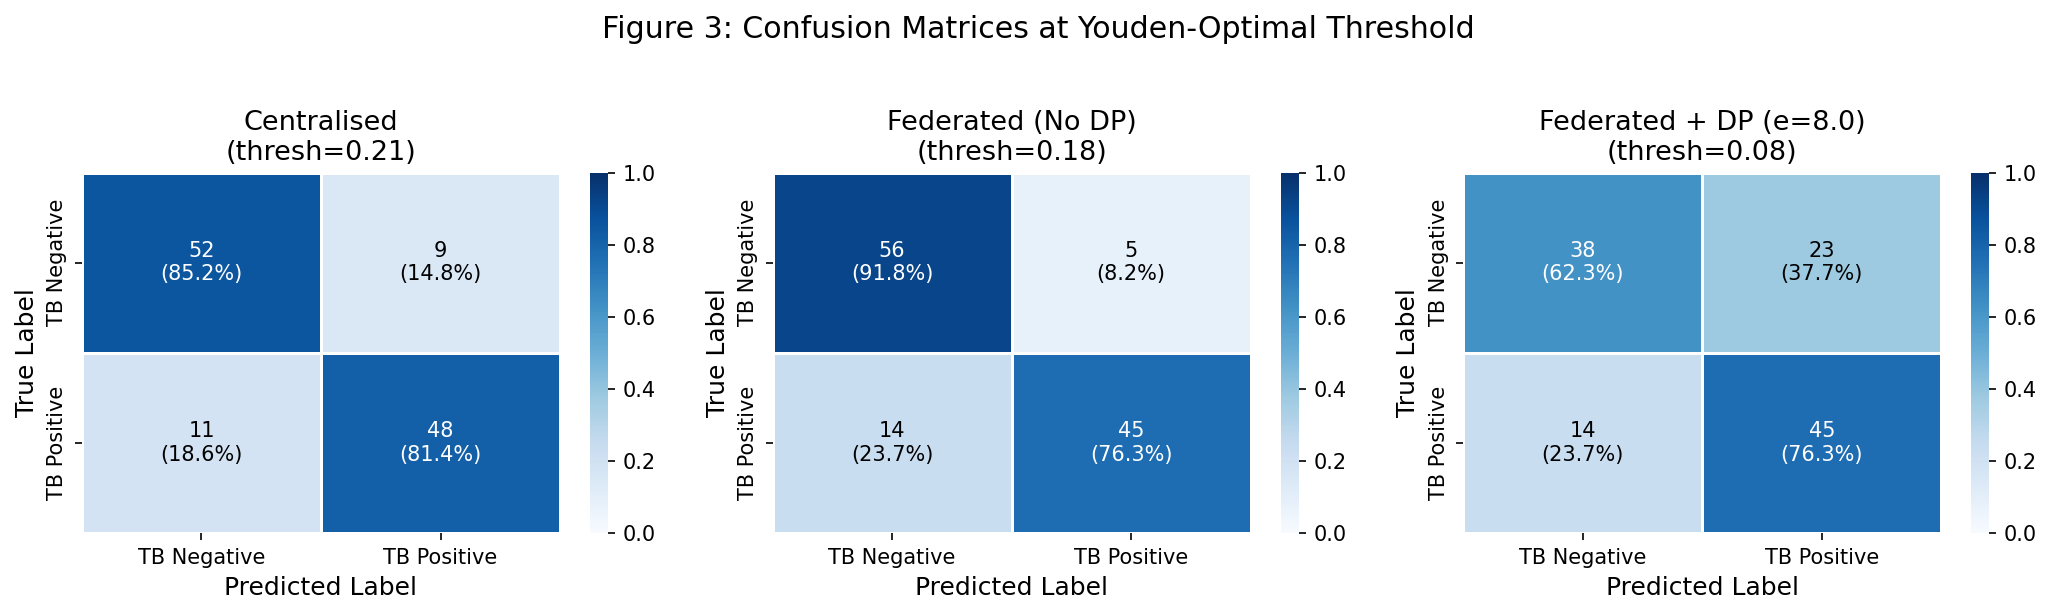

Figure 3 saved.


In [4]:
fig3, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (mname, yp) in zip(axes, model_preds.items()):
    thr    = youden_threshold(y_true, yp)
    y_pred = (yp >= thr).astype(int)
    plot_confusion_matrix(y_true, y_pred, title=f"{mname}\n(thresh={thr:.2f})", ax=ax)
fig3.suptitle("Figure 3: Confusion Matrices at Youden-Optimal Threshold", y=1.02)
plt.tight_layout()
save_figure(fig3, "fig3_confusion_matrices", paths["figures"], paths["paper_figures"], dpi=300)
plt.show()
print("Figure 3 saved.")

## Tables - LaTeX export

I export Table 1 (full metrics with CI) and Table 2 (statistical comparison) in LaTeX format for direct inclusion in the manuscript.

In [6]:
# Table 1
t1_path = paths["tables"] / "full_metrics_table.csv"
if t1_path.exists():
    t1 = pd.read_csv(t1_path)
    print("Table 1 preview:")
    print(t1.to_string(index=False))
    latex1 = t1.to_latex(
        index=False, float_format="%.4f",
        caption="Model performance on held-out test set (95\\% bootstrap CI, n=1000).",
        label="tab:metrics",
    )
    out1 = paths["paper_tables"] / "table1_metrics.tex"
    with open(out1, "w", encoding="utf-8") as f:
        f.write(latex1)
    print(f"\nTable 1 LaTeX saved: {out1}")
else:
    print("full_metrics_table.csv not found. Run Notebook 11 first.")

# Table 2
t2_path = paths["tables"] / "statistical_comparison.csv"
if t2_path.exists():
    t2 = pd.read_csv(t2_path)
    latex2 = t2.to_latex(
        index=False,
        caption="Statistical comparison: Centralised vs Federated+DP.",
        label="tab:stats",
    )
    out2 = paths["paper_tables"] / "table2_statistical_tests.tex"
    with open(out2, "w", encoding="utf-8") as f:
        f.write(latex2)
    print(f"Table 2 LaTeX saved: {out2}")
else:
    print("statistical_comparison.csv not found. Run Notebook 11 first.")

Table 1 preview:
            Model            Metric  Estimate  CI Lower  CI Upper      95% CI
      Centralised           AUC-ROC    0.8939    0.8333    0.9432 0.833–0.943
      Centralised           AUC-PRC    0.9113    0.8554    0.9536 0.855–0.954
      Centralised       Sensitivity    0.8136    0.7167    0.9033 0.717–0.903
      Centralised       Specificity    0.8525    0.7592    0.9310 0.759–0.931
      Centralised               PPV    0.8421    0.7447    0.9299 0.745–0.930
      Centralised                F1    0.8276    0.7500    0.8909 0.750–0.891
      Centralised Balanced Accuracy    0.8330    0.7663    0.8927 0.766–0.893
Federated (No DP)           AUC-ROC    0.9086    0.8529    0.9527 0.853–0.953
Federated (No DP)           AUC-PRC    0.9164    0.8577    0.9598 0.858–0.960
Federated (No DP)       Sensitivity    0.7627    0.6491    0.8621 0.649–0.862
Federated (No DP)       Specificity    0.9180    0.8437    0.9828 0.844–0.983
Federated (No DP)               PPV    0.9000  